In [ ]:
# --- import ---
import os
import sys
#from PIL import Image
#import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
#import torch.nn as nn
#import torch.optim as optim
# from sklearn.metrics import confusion_matrix, f1_score
# from sklearn.model_selection import train_test_split
import numpy as np

sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils.data_loader import ButterflyDataset
from src.baseline.train import train_model
from src.baseline.evaluate import ClassificationEvaluator, LearningCurveTracker
from src.utils.save_exp import save_experiment
from src.baseline.model import BaselineCNN

# 0. Baseline (with raw dataset)

In [2]:
# --- data load and prep ---
BATCH_SIZE = 32
IMAGE_SIZE = 64

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {DEVICE}.")

data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

path = "../data/raw"
img_dir = os.path.join(path, 'train')

full_train_df = pd.read_csv('splits/full_train_split.csv')
train_df = pd.read_csv('splits/train_split.csv')
val_df = pd.read_csv('splits/val_split.csv')
test_df = pd.read_csv('splits/test_split.csv')

train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_dataloader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_dataloader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

full_train_dataset = ButterflyDataset(df=full_train_df, img_dir=img_dir, transform=data_transform)
full_train_dataloader = data.DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = sorted(test_df['label'].unique().tolist())
C = len(class_names)

Working on cuda.


In [ ]:
# --- train or load model ---

train = 1

output_dir = '../src/baseline/saved'
output_path = os.path.join(output_dir, 'raw_weights.pth')

if train:
    epochs = 10
    model_raw, history_raw = train_model(   
        data_loader=train_dataloader,
        # val_loader=val_dataloader,
        epochs=epochs,
        device=DEVICE,
        n_classes=C
    )
    torch.save(model_raw.state_dict(), output_path)
else:
    model_raw = BaselineCNN(num_classes=C)
    if not os.path.exists(output_path):
        raise FileNotFoundError(f"No model found on {output_path}.")
    model_raw.load_state_dict(torch.load(output_path, map_location=DEVICE))
    model_raw = model_raw.to(DEVICE)
    model_raw.eval()

    history_path = os.path.join(output_dir, 'run_20260530_023037/training_history.csv')
    history_raw = pd.read_csv(history_path)
    history_raw = history_raw.to_dict(orient='list')


Best epoch: {'epoch': 595, 'train_loss': 0.0286203731190074, 'val_loss': 0.0, 'train_acc': 0.28125, 'val_acc': 0.0}


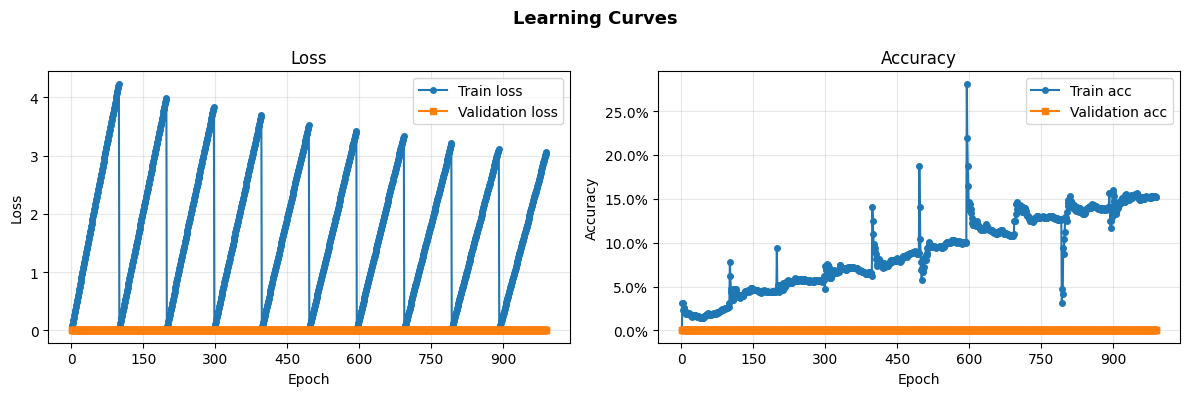

In [7]:
# --- Learning curves ---
tracker = LearningCurveTracker()
for epoch in range(len(history_raw['train_loss'])):
    tracker.update(
        train_loss = history_raw['train_loss'][epoch],
        train_acc  = history_raw['train_acc'][epoch],
        val_loss   = history_raw['val_loss'][epoch],
        val_acc    = history_raw['val_acc'][epoch],
    )
print("Best epoch:", tracker.best_epoch("train_loss")) # Changed tracking target to train_loss since val is flat here
tracker.plot()

In [8]:
# --- test ---
model_raw.eval()
all_preds = []
all_trues = []
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(DEVICE)
        outputs = model_raw(images)
        _, preds = torch.max(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_trues.extend(labels.cpu().numpy())

y_true = np.array(all_trues)
y_pred = np.array(all_preds)


Class                         Precision      Recall          F1     Support
---------------------------------------------------------------------------
ADONIS                           0.4762      0.7143      0.5714          14
AFRICAN GIANT SWALLOWTAIL        0.0000      0.0000      0.0000          12
AMERICAN SNOOT                   0.0000      0.0000      0.0000          12
AN 88                            0.2000      0.0714      0.1053          14
APPOLLO                          0.1184      0.6429      0.2000          14
ATALA                            0.4400      0.6875      0.5366          16
BANDED ORANGE HELICONIAN         0.4286      0.2000      0.2727          15
BANDED PEACOCK                   0.0000      0.0000      0.0000          13
BECKERS WHITE                    0.0693      0.5385      0.1228          13
BLACK HAIRSTREAK                 0.1525      0.6429      0.2466          14
BLUE MORPHO                      0.0000      0.0000      0.0000          12
BLUE SPOTTE

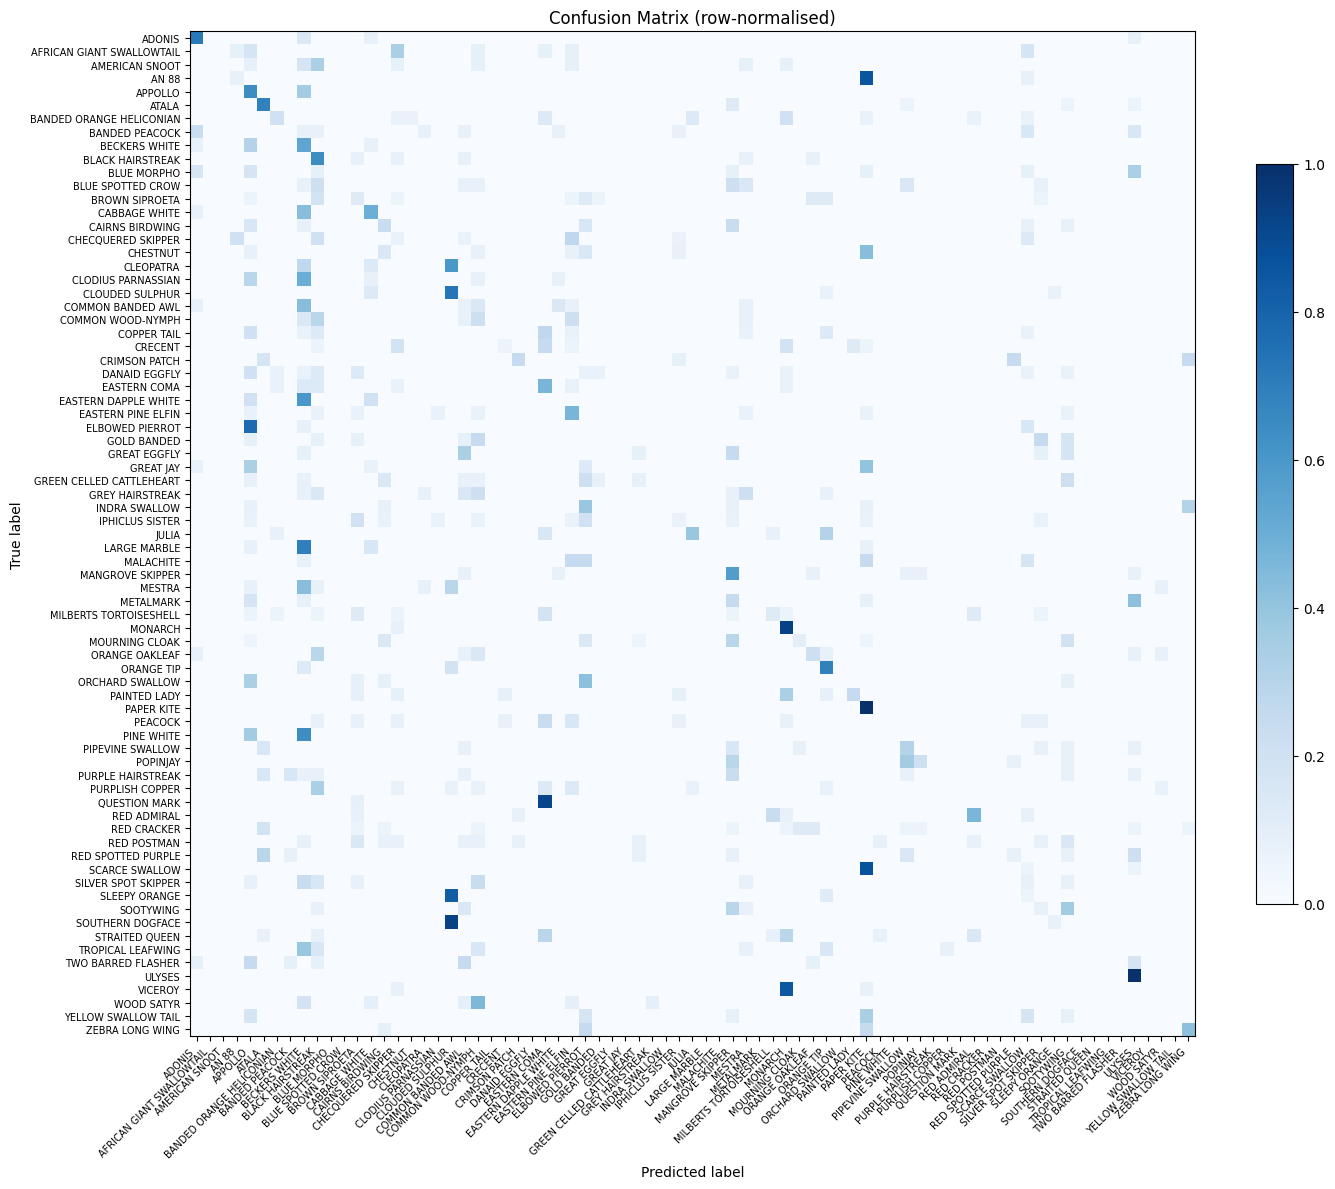

In [9]:
# --- Evaluator ---
ev_raw = ClassificationEvaluator(class_names=class_names, n_classes=C)
ev_raw.update(y_true, y_pred)
report = ev_raw.compute()
ev_raw.print_report(report)
ev_raw.plot_confusion_matrix(report)

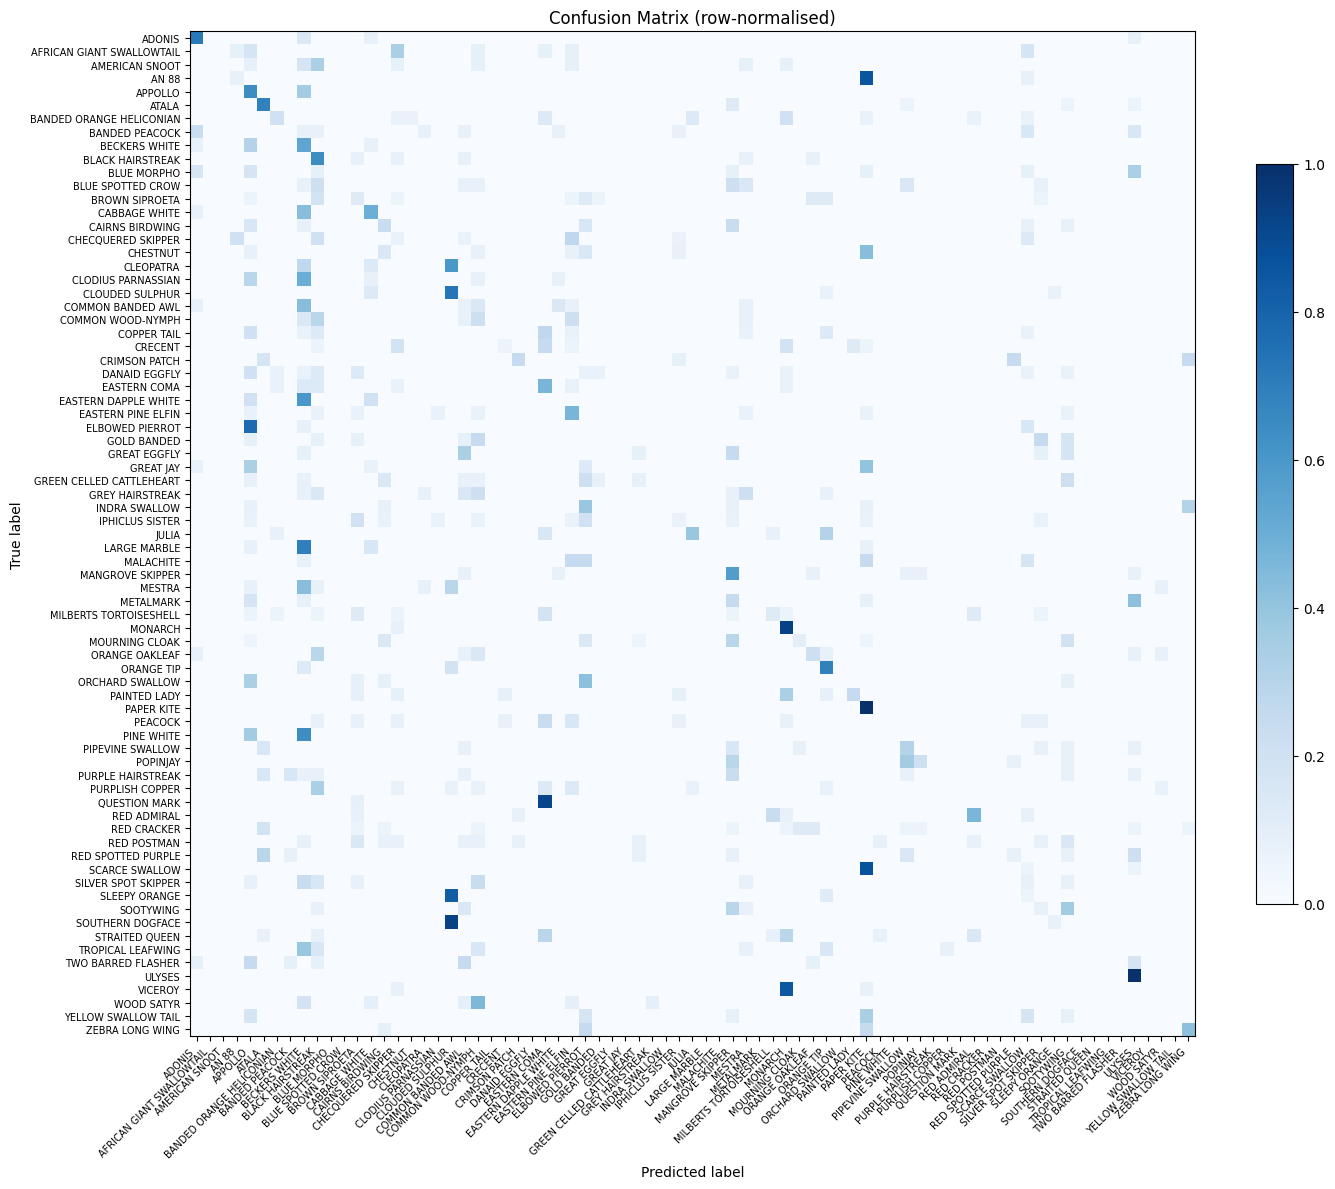

'../src/baseline/saved\\run_20260530_023037'

In [ ]:
# --- Save ---
config = {
    "augmentation": "none",
    "batch_size": BATCH_SIZE,
    "epochs": epochs,
}

save_experiment(model_raw, history_raw, config, ev_raw, "../src/baseline/saved")

# 1. Autoencoders

# 2. GANs

# 3. Diffusion Models

# 4. Comparison